## Boosting Techniques   Assignment

1. What is Boosting in Machine Learning? Explain how it improves weak
learners.?

Ans:Key Idea of Boosting:

 - A weak learner (e.g., a shallow decision tree, often called a decision stump) may only classify data slightly better than random (say, 55–60% accuracy).

 - Boosting works by training weak learners sequentially, where each new learner focuses more on the mistakes made by the previous learners.

 - The final model is a weighted combination (ensemble) of all the weak learners, leading to much better performance.

 - Boosting in machine learning is an ensemble method that combines multiple weak learners (models that perform slightly better than random guessing) to create a strong, accurate predictive model.

 -  It works by training learners
 sequentially, with each new model focusing on correcting the errors made by its predecessors.

 - This iterative process, often adjusting the weights of misclassified data points, helps to significantly improve the overall model's performance and reduce both bias and variance.


---How Boosting Works:

1. Assign equal weights to all training samples.
At the beginning, every sample is equally important.

2. Train the first weak learner.
It makes predictions, and errors are recorded.

3. Increase weights of misclassified samples.
Misclassified examples get higher weights so that the next learner pays more attention to them.

4. Train the next weak learner on the updated dataset.
This learner focuses on the harder cases that the previous one got wrong.

5. Repeat for multiple learners.
Each learner is added sequentially, correcting the mistakes of the previous ones.

6. Combine learners (weighted voting or averaging).
The final prediction is made by taking a weighted majority vote (for classification) or weighted sum (for regression).

---Example:

 - Suppose we have 3 weak learners with accuracies slightly above random guessing.

 - Boosting makes them focus on the hard-to-classify data points.

 - When combined, they complement each other’s weaknesses, resulting in a model with high accuracy.

---Why Boosting Improves Weak Learners:

 - Weak learners on their own are not powerful enough to capture complex patterns.

 - By sequentially focusing on errors, boosting ensures that:

 - Hard examples are given more importance.

 - Bias is reduced (models learn better patterns).

 - The final ensemble has much better generalization capability.

---Popular Boosting Algorithms:

 - AdaBoost (Adaptive Boosting) – first popular boosting method, uses exponential weight adjustment.

 - Gradient Boosting – uses gradient descent to optimize errors.

 - XGBoost, LightGBM, CatBoost – modern scalable and efficient implementations widely used in competitions and industry.

 Boosting converts multiple weak learners (like small decision trees) into a strong, accurate model by training them sequentially and focusing more on difficult cases at each step.

2. What is the difference between AdaBoost and Gradient Boosting in terms
of how models are trained?

Ans:1.  AdaBoost (Adaptive Boosting):

---Training method:

 - Start with all training samples having equal weights.

 - Train a weak learner (usually a shallow decision tree).

 - Increase weights of misclassified samples so that the next learner focuses more on them.

 - Combine learners using weighted voting (classification) or weighted sum (regression).

 - Key Idea: Focuses on re-weighting data points to emphasize mistakes made by previous learners.

2.  Gradient Boosting:

---Training method:

 - Start with an initial prediction (e.g., mean value for regression).

 - Compute residual errors (difference between predictions and actual values).

 - Train the next weak learner to predict these residuals (errors).

 - Update the overall model by adding the new learner’s predictions (scaled by a learning rate).

 - Key Idea: Learners are trained to reduce the residual error of the previous model using gradient descent.


AdaBoost : Adjusts weights on data points to force new models to correct mistakes.

Gradient Boosting : Fits new models to residual errors using gradient descent to minimize loss.

3.  How does regularization help in XGBoost?


Ans:Regularization in XGBoost helps prevent overfitting by adding penalty terms to the objective function, which discourages overly complex models. This ensures the model generalizes well to unseen data rather than memorizing the training data.



How Regularization Helps in XGBoost:

1. Adds penalty for complex trees:

 - In XGBoost, the objective function is:

𝑂
𝑏
𝑗
=
Loss
+
Ω
(
𝑓
)
Obj=Loss+Ω(f)

 - Where:

Loss → measures prediction error (like log loss, MSE).

Ω(f) → regularization term for tree complexity.

Ω
(
𝑓
)
=
𝛾
𝑇
+
1
2
𝜆
∑
𝑤
𝑗
2
Ω(f)=γT+
2
1
	​

λ∑w
j
2
	​


𝑇
T = number of leaves (more leaves = more complexity).

𝑤
𝑗
w
j
	​

 = weight (score) of leaf
𝑗
j.

𝛾
γ = penalty for adding a new leaf.

𝜆
λ = L2 regularization term (shrinks leaf weights).

- This prevents trees from becoming too deep or too “specific” to training data.

2. Controls overfitting:

 - Without regularization, boosting may keep adding trees that fit noise in the data.

 - With penalties (
𝜆
,
𝛾
λ,γ), XGBoost avoids overly complex trees and generalizes better.

3. Stabilizes leaf weights:

 - L1 regularization (α) → makes some leaf weights exactly 0, similar to Lasso → feature selection effect.

 - L2 regularization (λ) → shrinks weights smoothly, like Ridge regression → reduces variance.

 - This prevents extreme predictions and improves robustness.

4. Balances bias-variance tradeoff:

 - Regularization discourages very complex trees → increases bias a little but reduces variance a lot.

 - The result is a more stable, generalizable model.

---Intuition

 - Traditional Gradient Boosting: “Fit residuals until perfect.” (risk of overfitting)

 - XGBoost with regularization: “Fit residuals, but keep the model simple and penalize unnecessary complexity.”

Some other
 - L1 Regularization (alpha or reg\_alpha):
This adds the sum of the absolute values of the leaf weights to the cost function. It encourages sparsity, meaning it can drive the weights of less important features to zero, effectively performing feature selection.


 - L2 Regularization (lambda or reg\_lambda):
This adds the sum of the squares of the leaf weights to the cost function. It helps to prevent large weights and reduces the impact of individual observations on the predictions.


 - Max Depth (max\_depth):
This limits the maximum depth to which individual trees in the ensemble can grow. Shorter trees are generally less complex and less prone to overfitting.

 - Gamma (min\_split\_loss or min\_gain\_to\_split):
This parameter controls the minimum loss reduction required to make a further partition on a leaf node. A higher gamma value means more conservative splitting and more pruning, leading to simpler trees.


4. Why is CatBoost considered efficient for handling categorical data?

Ans:CatBoost is considered efficient for handling categorical data primarily due to its innovative internal mechanisms that reduce the need for manual preprocessing and mitigate common issues associated with categorical feature encoding.

Key reasons for its efficiency include:

 - Ordered Target Encoding:
CatBoost employs a unique target-based encoding scheme called Ordered Target Encoding. This method calculates target statistics for each category based on a permutation of the data, ensuring that the encoding for a given data point only uses information from previous data points in the permutation. This approach helps prevent target leakage and reduces overfitting, which are common problems with traditional target encoding methods.

 - Ordered Boosting:
CatBoost introduces "Ordered Boosting," a technique where the gradient computations for each tree are based on a different subset of the data, ordered to prevent the current tree from "seeing" the target values of future data points. This further reduces overfitting, especially when dealing with categorical features.

 - Automatic Categorical Feature Handling:
CatBoost automatically identifies and handles categorical features without requiring explicit one-hot encoding or label encoding by the user. This significantly simplifies the preprocessing pipeline and saves time and effort.

 - Oblivious Trees:
CatBoost uses oblivious trees, where the same split condition is applied at each level of the tree. This symmetric structure leads to faster prediction times and can also have a regularization effect, further preventing overfitting and contributing to model robustness.

--- Why CatBoost is Efficient for Categorical Data
1. No need for one-hot encoding:

 - Normally, categorical features (like "color" = red/blue/green) are converted using one-hot encoding or label encoding before training.

 - One-hot encoding → increases dimensionality (sparse features).

 - Label encoding → imposes an artificial order (red=0, blue=1, green=2).

 - CatBoost avoids these issues with a special encoding technique.

2. Uses Target-based Statistical Encoding (Ordered Target Statistics)

 - CatBoost transforms categorical features into numerical values using target statistics:

 - Encoded Value
=
Sum of target values for category
Number of occurrences of category
Encoded Value=
Number of occurrences of category
Sum of target values for category
	​
 - But it does this in a clever, unbiased way:

 - Instead of using the whole dataset (which causes data leakage), it uses random permutations of data.

 - Each sample is encoded based only on previous samples in the permutation → avoids target leakage.

 - This makes CatBoost highly accurate on categorical-heavy datasets.

3. Efficient Handling of High Cardinality

 - If you have thousands of unique categories (e.g., user IDs, product IDs), one-hot encoding would explode in size.

 - CatBoost efficiently computes target statistics without blowing up memory or computation.

4. Built-in Feature Combinations

 - CatBoost can automatically generate combinations of categorical features (like "city + device type").

 - This helps capture non-linear interactions between categorical features that manual encoding would miss.

5. Reduced Preprocessing Effort

 - With CatBoost, you can directly feed categorical columns (like ['city', 'gender', 'color']) without heavy preprocessing.

 - This saves time, reduces errors, and often improves performance.

---Summary

 - CatBoost is efficient for categorical data because:

 - No need for manual encoding (one-hot/label).

 - Uses ordered target statistics to avoid data leakage.

- Handles high-cardinality categorical features efficiently.

- Captures feature interactions automatically.

- Minimizes preprocessing effort while boosting accuracy.

5. What are some real-world applications where boosting techniques are
preferred over bagging methods?


Ans:Boosting and bagging are both ensemble learning methods, but they excel in different scenarios. Boosting, particularly algorithms like XGBoost and LightGBM, often outperforms bagging (like Random Forests) when high accuracy on a single prediction is crucial and computational resources are less of a concern. Bagging, on the other hand, is preferred when stability, robustness, and reduced overfitting are prioritized.

1. Fraud Detection & Risk Modeling (Finance/Insurance):

 - Boosting excels when the goal is to capture rare, complex patterns (like fraudulent transactions or insurance claims).

 - Fraudulent events are often minority cases with subtle signals, and boosting’s sequential error correction helps in detecting them better than bagging.

2. Customer Churn Prediction (Telecom, SaaS)

 - Boosting is useful when small differences in features (usage frequency, call duration, login activity) separate churners from loyal customers.

 - Models like XGBoost and LightGBM often outperform Random Forests in Kaggle churn prediction competitions.

3. Click-Through Rate (CTR) & Ad Targeting (Online Advertising)

 - Extremely common in tech companies like Google, Facebook, TikTok.

 - Boosting methods handle large-scale, high-dimensional, sparse categorical data (like user demographics, browsing behavior) better.

 - Gradient boosting dominates in production recommender and ad-ranking systems.

4. Credit Scoring & Loan Default Prediction (Banking)

 - Credit scoring requires high accuracy with imbalanced data (few defaults compared to many repays).

 - Boosting (especially gradient boosting) captures subtle feature interactions—important for regulatory-grade risk models.

5. Medical Diagnosis & Patient Risk Prediction

 - Boosting works well in structured healthcare data (lab test results, patient history).

 - E.g., predicting cancer risk, hospital readmission, or disease progression, where interpretability + accuracy matter.

 - Tree-based boosting models provide feature importance insights for clinicians.

6. Search Ranking (Information Retrieval, E-commerce, Search Engines)

 - Boosting algorithms (especially LambdaMART, a boosted tree method) are used in ranking tasks:

 - Google’s search ranking signals

 - Amazon product ranking

 - Netflix recommendation ranking

7. Competitions & Benchmarking (Kaggle, Data Science Challenges)

 - Boosting methods (XGBoost, LightGBM, CatBoost) are the go-to models in structured/tabular data challenges.

 - They often outperform Random Forests when:

 - Data has many correlated features.

 - Class imbalance exists.

 - The signal is buried under noise.

---summary:

Use bagging (Random Forests) when variance reduction is more important (robust, less prone to overfitting, better for noisy data).

Use boosting (XGBoost, LightGBM, etc.) when you need high predictive accuracy, complex pattern recognition, and performance on imbalanced/structured data.

In [2]:
# 6. Datasets:
#● Use sklearn.datasets.load_breast_cancer() for classification tasks.
#● Use sklearn.datasets.fetch_california_housing() for regression
#tasks.
#Question 6: Write a Python program to:
#● Train an AdaBoost Classifier on the Breast Cancer dataset
#● Print the model accuracy


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize AdaBoost Classifier
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)

# Train the model
ada_clf.fit(X_train, y_train)

# Predictions
y_pred = ada_clf.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("AdaBoost Classifier Accuracy:", accuracy)


AdaBoost Classifier Accuracy: 0.956140350877193


In [4]:
# 7. Write a Python program to:
#● Train a Gradient Boosting Regressor on the California Housing dataset
#● Evaluate performance using R-squared score.


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score

# Load California Housing dataset
data = fetch_california_housing()
X, y = data.data, data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                max_depth=3, random_state=42)

# Train the model
gbr.fit(X_train, y_train)

# Predictions
y_pred = gbr.predict(X_test)

# Evaluate R-squared score
r2 = r2_score(y_test, y_pred)
print("Gradient Boosting Regressor R² Score:", r2)


Gradient Boosting Regressor R² Score: 0.8004451261281281


In [5]:
# 8. Write a Python program to:
#● Train an XGBoost Classifier on the Breast Cancer dataset
#● Tune the learning rate using GridSearchCV
#● Print the best parameters and accuracy .

import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Load the Breast Cancer dataset
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = cancer.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost Classifier
xgb_model = XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)

# Define the parameter grid for GridSearchCV, focusing on 'learning_rate'
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3]
}

# Initialize GridSearchCV
# cv=5 indicates 5-fold cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Perform GridSearchCV to find the best learning rate
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

# Train the final model with the best parameters
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test)

# Calculate and print the test set accuracy
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy with best parameters: {test_accuracy:.4f}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best parameters: {'learning_rate': 0.2}
Best cross-validation accuracy: 0.9670
Test set accuracy with best parameters: 0.9561


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [13:44:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


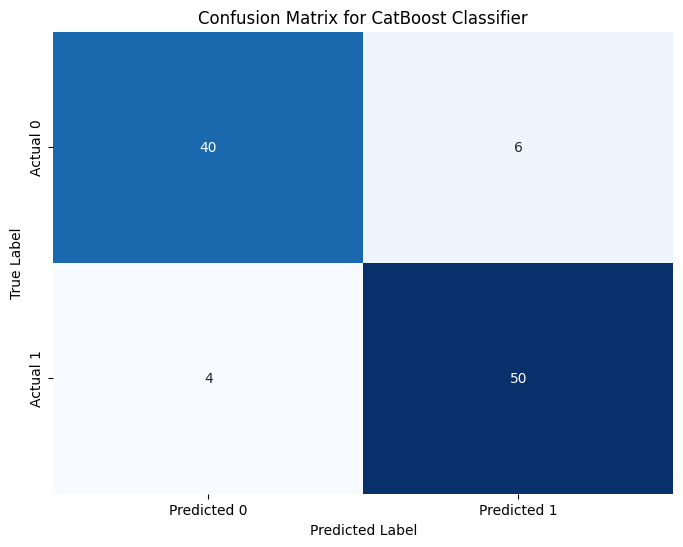

Model Accuracy: 0.9000


In [22]:
# 9. Write a Python program to:
#● Train a CatBoost Classifier
#● Plot the confusion matrix using seaborn.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from catboost import CatBoostClassifier

# 1. Prepare Sample Data
# Create a synthetic dataset for demonstration purposes
np.random.seed(42)
data_size = 500
X = pd.DataFrame(np.random.rand(data_size, 5), columns=[f'feature_{i}' for i in range(5)])
y = (X['feature_0'] + X['feature_1'] > 1.0).astype(int) # Simple binary classification target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a CatBoost Classifier
# Initialize and train the CatBoostClassifier
# For simplicity, we'll use default parameters. You can tune these for better performance.
model = CatBoostClassifier(iterations=100,  # Number of boosting rounds
                           learning_rate=0.1, # Step size shrinkage
                           depth=6,           # Depth of the trees
                           loss_function='Logloss', # Loss function for binary classification
                           verbose=0,         # Suppress training output
                           random_seed=42)

model.fit(X_train, y_train)

# 3. Make Predictions
y_pred = model.predict(X_test)

# 4. Calculate and Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CatBoost Classifier')
plt.show()

# Optional: Print accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

10. You're working for a FinTech company trying to predict loan default using
customer demographics and transaction behavior.
The dataset is imbalanced, contains missing values, and has both numeric and
categorical features.
Describe your step-by-step data science pipeline using boosting techniques:

● Data preprocessing & handling missing/categorical values

● Choice between AdaBoost, XGBoost, or CatBoost

● Hyperparameter tuning strategy

● Evaluation metrics you'd choose and why

● How the business would benefit from your model.


Ans:Loan default prediction: a step-by-step data science pipeline
Predicting loan default is crucial for financial institutions to manage risk and maintain profitability. Here's a step-by-step data science pipeline using boosting techniques:


1. Data preprocessing and handling missing/categorical values:

 - Load and inspect data: Begin by loading the dataset and performing an initial exploration (EDA). Understand data types, distributions, and identify features containing missing values or requiring special handling.

 - Missing value imputation: For numerical features, consider strategies like mean, median imputation, or more advanced methods like regression imputation to estimate and fill in missing values. For categorical features, replacing missing values with a designated category (e.g., "Unknown") or using modal imputation are viable options.

 - Outlier treatment: Identify and handle outliers, as they can significantly impact model training. Techniques like capping (e.g., replacing values beyond a certain percentile with the percentile value) or Winsorization can be used.

 - Categorical feature encoding:
Label Encoding: Convert categorical labels into numerical representations, assigning a unique integer to each category.

 - One-Hot Encoding: Create new binary columns for each category within a feature, indicating the presence or absence of that category.

 - Target Encoding/Ordered Target Encoding: Encode categorical features based on the target variable, particularly helpful in reducing overfitting and enhancing performance, says Medium.

 - Note that CatBoost can handle categorical features natively, potentially simplifying this step.

 - Feature scaling: For certain algorithms (like Logistic Regression and Neural Networks) that are sensitive to feature scales, standardize or normalize numerical features to ensure they are within a standard range (e.g., 0-1).

 - Feature engineering: Create new, insightful features from existing ones. Examples include:
Debt-to-income ratio.
Payment history features (e.g., number of missed payments in the last X months).
Transaction spikes near salary day.

 - Feature selection: Select the most impactful features for the model using techniques like Recursive Feature Elimination with Cross-Validation (RFECV) or methods based on feature importance from tree-based algorithms. This can help improve model interpretability, reduce training time, and potentially boost predictive accuracy.


2. Choice between AdaBoost, XGBoost, or CatBoost:

 - AdaBoost: A simpler boosting algorithm, often effective on smaller datasets.

 - XGBoost: A powerful and scalable implementation of gradient boosting, known for its speed and performance on diverse datasets.it utilizes regularization to prevent overfitting.

 - CatBoost: Excels with datasets containing categorical features, natively handling them without requiring extensive preprocessing, notes Analytics Vidhya. It uses symmetric decision trees and a novel ordered encoding method. It may be slower than XGBoost for training but can provide better performance with categorical data.

 - The choice depends on the dataset's characteristics and the specific needs of the project:

 - Categorical-rich datasets: CatBoost is often the preferred choice due to its superior handling of categorical features.

 - Performance and scalability: XGBoost is a strong contender for its speed, scalability, and robust performance on structured/tabular data.

 - Simpler problems or baseline models: AdaBoost can serve as a good starting point, especially for smaller datasets.

 - Given the presence of both numerical and categorical features in the loan default dataset, CatBoost is a strong candidate, especially for its ability to handle categorical features directly.

 - However, thorough experimentation with both CatBoost and XGBoost (after proper categorical encoding for XGBoost) is recommended.

3. Hyperparameter tuning strategy:

 - Grid Search (GridSearchCV): Systematically explores all combinations of predefined hyperparameter values.

 - Random Search (RandomizedSearchCV): Samples a fixed number of hyperparameter combinations from the specified ranges.

 - Bayesian Optimization: An advanced technique that builds a probabilistic model of the hyperparameter space to guide the search for optimal values more efficiently than grid or random search.

 - Use k-fold cross-validation (e.g., stratified 5-fold cross-validation) in conjunction with hyperparameter tuning to ensure robust and generalizable model performance.

4. Evaluation metrics:

 - Since loan default datasets are often imbalanced (fewer defaults than non-defaults), accuracy alone is insufficient.

 --- Key metrics to consider include:

 - Precision: Proportion of predicted defaults that are actually defaults.

 - Recall (Sensitivity): Proportion of actual defaults that are correctly identified. Crucial for financial risk management, as failing to identify a defaulter poses significant risk.

 - F1-Score: The harmonic mean of precision and recall, providing a balanced evaluation of the model's performance on the minority class (defaults).

 - AUC-ROC (Area Under the Receiver Operating Characteristic curve): Measures the model's ability to distinguish between classes across various thresholds.

 - Precision-Recall Curve: Visualizes the trade-off between precision and recall at different thresholds, offering valuable insights into model performance on the minority class.

 - Confusion Matrix: Provides a detailed breakdown of true positives, true negatives, false positives, and false negatives. Helpful for understanding misclassification patterns and assessing risk.

 - Emphasis should be placed on Recall and F1-Score, as accurately identifying defaulters (the minority class) is often a priority for financial institutions.

5. Business benefits:

 - Reduced Non-Performing Asset (NPA) Ratios: Predictive models help identify and mitigate potential defaults early, leading to a healthier loan portfolio and lower NPA ratios.

 - Smarter Loan Approvals: By analyzing diverse data points and behavioral patterns, the model provides a more accurate assessment of creditworthiness beyond traditional credit scores.

 - Improved Risk Management: Early detection of default signals and portfolio risk management strategies allow for proactive interventions and tailored collection/recovery strategies.

 - Reduced Manual Review Costs: Automation of risk classification streamlines the approval process, potentially reducing the need for manual underwriting.

 - Personalized Lending: Predictive analytics enables lenders to tailor loan products and terms based on individual borrower profiles, leading to better engagement and lower churn.

 - Enhanced Regulatory Compliance: Transparent and explainable models support audit requirements and build confidence among investors, stakeholders, and regulators.

 - Faster Loan Disbursements: Low-risk applicants can benefit from faster loan processing due to streamlined risk assessment.

By implementing a robust loan default prediction model, fintech companies can make data-driven decisions that reduce risk, optimize operations, and drive profitability.



